 This notebook presents my attempt to build a Small Language Model (SLM) from scratch. While developing this project, I referred to several learning resources and research materials, which are listed in the README file. The goal of this notebook is to understand the core components involved in training a language model, including data processing, model architecture, training, and text generation.

In [1]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


 The TinyStories dataset will be used to train the Small Language Model.
 It contains approximately 2 million stories for training and around
 20,000 stories for validation. Loading the dataset may take some time.

In [2]:
from datasets import load_dataset

df = load_dataset("roneneldan/TinyStories")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [3]:
df

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})

In [4]:
df.shape

{'train': (2119719, 1), 'validation': (21990, 1)}

In [5]:
type(df)

datasets.dataset_dict.DatasetDict

 Step 1: Tokenization
 Before feeding the text data into the Small Language Model (SLM), it must be
 converted into a numerical format. This is done through a process called
 tokenization, where text is broken into smaller units called tokens.

 In this project, we use Byte Pair Encoding (BPE), a subword tokenization
 technique. BPE is more efficient than word-level or character-level
 tokenization because it can handle rare words, reduce vocabulary size,
 and better capture patterns in language.

Each row is a story; each token receives an ID and is merged.
We store token IDs in a .bin file

 The tokenized data is stored in a .bin file so it can be saved directly on disk.
 This avoids loading everything into RAM,
 making the processing faster and more memory efficient. The .bin file can also
 be reused during training, so the dataset does not need to be tokenized again.

We will also need to make sure that it is memory mapped using np.memmap

Batching speeds up processing

In [6]:
pip install tiktoken

In [7]:
from tqdm.auto import tqdm
import tiktoken
import os
import numpy as np

In [8]:
encoding = tiktoken.get_encoding("gpt2")

In [9]:
def processing(sample_text):
    ids = encoding.encode_ordinary(sample_text['text'])
    out = {'ids':ids,'len':len(ids)}
    return out

In [10]:
if not os.path.exists("train.bin"):
    tokenized = df.map(
        processing, # our token processing function defined above....basically we are mapping teh data here...:)
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # this tells you the total bits, so 16 here so 2^16 possible tokens which very well fits our training data
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024
        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # We will Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Here we write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()


tokenizing the splits (num_proc=8):   0%|          | 0/2119719 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/21990 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

Now we create input-output pairs...

Define these settings first:

Context size (how much history the model uses before predicting next token)
we use context_size = 4

 After tokenization, the model no longer sees the original words; it only
 processes numerical token IDs. For example, a sequence might look like
 [23, 43, 56, 34, 7, 3, ...].

 If the context size is 4, the model takes the first four tokens
 [23, 43, 56, 34] as input and tries to predict the next token [7].
 This process is repeated across the entire train.bin dataset, which may
 contain over 100 million token IDs.

 At each step, the input sequence moves forward by one token (shifted by 1),
 and the model learns to predict the next token in the sequence.

Now we need batches (batch_size=6) to speed up parameter updates during backpropagation

Now we have input and output tensors

With context size 4, each row has four prediction targets

 Example:
 X1 = [23, 4, 2, 66] and y1 = [4, 2, 66, 8]

 For this input–output pair, the model is effectively learning to make
 multiple next-token predictions:
 - If the input is [23], the model predicts [4]
 - If the input is [23, 4], the model predicts [2]
 - If the input is [23, 4, 2], the model predicts [66]
 - If the input is [23, 4, 2, 66], the model predicts [8]

 In this way, the model learns to predict the next token at every position
 in the sequence.

 Here, random batches are sampled from the data.
 This means that sequences like X1, X2, etc., can be sampled from
 any position in the original tokenized data. Random sampling helps
 the model see diverse parts of the dataset during training and
 improves learning efficiency.

 I also implement memory locking to reserve GPU memory

In [11]:
def get_batch(split):
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

In the cell above, x1, x2, ... are stacked; ix selects random batch positions.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

In [13]:
class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

NOTE: It is important to have Layer Normalization,

In [14]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))
#This part of the code, i have introduced
#the attention mechanism of the transformer architecture...
    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)


        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

Below is the MLP architecture

In [15]:

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

Now I create the Transformer Block

In [16]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

 x = x + self.attn(self.ln1(x))
 x = x + self.mlp(self.ln2(x))

 These two lines implement residual (skip) connections, similar to those
 used in the ResNet architecture. Instead of replacing the input, the model
 adds the output of the attention and MLP layers back to the original input.

 Residual connections help gradients flow more easily through deep networks,
 reducing the vanishing gradient problem. This allows the model to retain
 important information from earlier layers and improves training stability
 and efficiency.

In [17]:

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)   #this is out logits matrix which i have explaine below...
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1) # the loss is cross entropy
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


# Now we look at how output is computed

 The output of the transformer block has the shape (4 × 768),
 where 4 represents the context size and 768 represents the
 embedding (hidden) dimension produced by the model.

 This output is then passed through the lm_head layer, which
 projects it into a matrix of size (4 × vocab_size). This matrix
 is called the logits matrix.

 Each row corresponds to a token in the input sequence, and each
 column corresponds to a token in the vocabulary. The logits
 represent the model's scores for predicting the next possible token.

 To make the prediction, these logits are converted into probabilities
 (usually using a softmax function). The token with the highest
 probability is selected as the predicted next token.

 In this way, the model predicts the next token for each position
 in the context sequence.

We compare outputs with targets, compute loss, and minimize it via backpropagation.



There will be 4 losses as the batch size we have taken is 4, so let these individual losses be L1,L2,L3 and L4, so the net Loss is L1+L2+L3+L4







 I have also initialized these trainable parameters:
These are basically the trainable params:
Token embedding layer (wte)
pos embedding layer (wpe)
1st attention block (layerNorm before)
QKV linear (c_attn)
output c_proj
2nd attention block (Layer norm before MLP)
MLP block (c_fc)
output c_proj
final layer norm
output head lm_head

In [18]:
config = GPTConfig(
    vocab_size=50257,
    block_size=128,       # here i have taken the context size of 128, i used 4 only for explanation
    n_layer=6, # no of layer is the transformer blocks' number that u use...
    n_head=6, #no of attention heads as in Multi Head Attention
    n_embd=384, # The embedding dimension .... try chnaging thinhs in this code here and there
    dropout=0.1,
    bias=True
)

model = GPT(config)

Loss uses cross entropy (negative log-likelihood) with target probabilities from logits.
and we want that value to be as close to 1 as possible
so for a batch of size four, we will have original output p1,p2,p3 and p4 whose values must be 1 iteratively and the predicted probabilities this will be for each item in batch

In [19]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

Note: AMP (Automatic Mixed Precision) automatically selects float precision to speed training.
This will dynamically make the processing faster and overall improved efficiency!
For example: when any matrix calculations are happening, then it will use FP16 and if any softmax computation is happening then it will use FP32 as we are cmputing exponentiation operation and we dont want any overflow/underflow error ocurring...

# Training Loop/Configuration

In [20]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 10000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

Here gradients are accumulated for 32 steps before updating parameters.

Using AdamW with weight decay; learning rate warms up then decays cosinely.

In [21]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipykernel_3892/2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Now we start pre-training the model

In [22]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 500: train loss 9.4206, val loss 9.4260
The current learning rate: 0.00007
Epoch 1000: train loss 8.4564, val loss 8.4590
The current learning rate: 0.00010
Epoch 1500: train loss 7.5060, val loss 7.5022
The current learning rate: 0.00010
Epoch 2000: train loss 6.6231, val loss 6.6178
The current learning rate: 0.00011
Epoch 2500: train loss 5.8620, val loss 5.8548
The current learning rate: 0.00013
Epoch 3000: train loss 5.3001, val loss 5.2945
The current learning rate: 0.00015
Epoch 3500: train loss 4.8244, val loss 4.8226
The current learning rate: 0.00017
Epoch 4000: train loss 4.4820, val loss 4.4806
The current learning rate: 0.00020
Epoch 4500: train loss 4.2113, val loss 4.2166
The current learning rate: 0.00023
Epoch 5000: train loss 3.9868, val loss 3.9928
The current learning rate: 0.00027
Epoch 5500: train loss 3.8110, val loss 3.8105
The current learning rate: 0.00030
Epoch 6000: train loss 3.6607, val loss 3.6593
The current learning rate: 0.00033
Epoch 6500: train

# Trained on T4 GPU for ~2 hours (10,000 steps); longer training improves output.

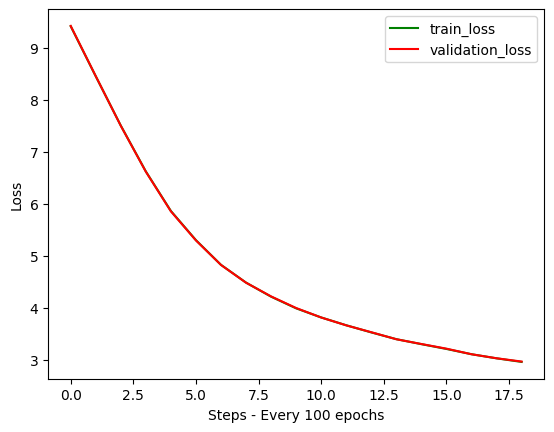

In [23]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [24]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


<All keys matched successfully>

In [25]:
sentence = "Once upon a time there was a girl."
context = (torch.tensor(encoding.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(encoding.decode(y.squeeze().tolist()))

Once upon a time there was a girl. She loved to play with her mommy went to play with her toys and showing her a face. She dropped the squirrel really magic spaceship and stopped very scared.

After a little girl's name went to explore the forest. She put on her gum steps and held the crayons into her hands. She kissed her littleinger and said, "Yes! You are a nice! I like to call the chimney. It's too nice toilies icy pill. You might have your stars staying!"

But her mother asked her mom. She said, "I am my namepillar decide, Jane. Can you if was notCRasured it? That's too big."

Sue felt proud of her head back. She hugged her. She said, "Can I flips it find herself, but we have it." They wiped the past-- trying to get the round. They spun could not like it had fun the ball.

When they were playing, they all


In [26]:
sentence = "A little girl went to the woods"
context = (torch.tensor(encoding.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(encoding.decode(y.squeeze().tolist()))

A little girl went to the woods and looking for a moment. She felt pink and determined to cut some water. She tried color, but playing, but the tall people flew, she fell into her window. She had no food hit her noseade her mouth and the squash snapped in the other's head.

The boy followed her and saw that it was enormous trunk there was on thick things was bright and successful. He herbs drew joy in the haircut, n troll when they started to shine rhythm and crawling everywhere he always peek.

After a while, the princess and and the two of the hallway stopped feeling of different songs. Everyone was never deep as good, the huge legs, she did. When she saw some cake and she told it it seemed as beautiful, she felt a wish and knew she lazy to keep his pan in the way. She thanked the small home warm house and she was all around with the yummy mouths. It was a furry little mechanic! The spicy day. And the problem.One
